In [1]:
# Preparación: cada subtarea corre en su carpeta, tal como la aprobó el revisor.
import os
from pathlib import Path
from IPython.display import Image, display

RAIZ = Path.cwd()

def mostrar_figuras(carpeta):
    for png in sorted(Path(carpeta).rglob("*.png")):
        display(Image(filename=str(png)))

# Tarea B — Atención escalada y codificación posicional (Vaswani et al., 2017)

**MMIA 6013 · Tarea de práctica (Taller 03 v2)** — Archivo: `tarea_b_atencion_escalada.ipynb`

Este notebook estudia dos ingredientes centrales de *Attention Is All You Need* (Vaswani et al., 2017): la atención escalada del producto punto,

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V,$$

y la codificación posicional sinusoidal que se suma a los embeddings de los tokens. El notebook se ejecuta de principio a fin sin errores y **todas las cifras se calculan en las celdas de código**; el texto solo las comenta.

## Parte 1 — Atención escalada

In [2]:
# Subtarea T1: código aprobado (se ejecuta en trabajo/T1/)
os.chdir(RAIZ / 'trabajo' / 'T1')

# -*- coding: utf-8 -*-
"""
T1 — Parte 1 — Atención escalada en NumPy
Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V
con softmax numéricamente estable (se resta el máximo de cada fila).

Matrices del enunciado:
  Q (2 consultas, dimensión 4)
  K (3 claves,   dimensión 4)
  V (3 valores,  dimensión 2)
"""

import json
import numpy as np

# ----------------------------------------------------------------------
# 1) Datos del enunciado
# ----------------------------------------------------------------------
Q = np.array([
    [1.0, 0.0, 1.0, 0.5],
    [0.0, 2.0, 0.0, 1.0],
], dtype=float)                      # (2, 4)

K = np.array([
    [1.0, 1.0, 0.0, 0.0],
    [0.0, 1.0, 1.0, 0.5],
    [1.0, 0.0, 1.0, 1.0],
], dtype=float)                      # (3, 4)

V = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [2.0, 2.0],
], dtype=float)                      # (3, 2)

d_k = Q.shape[1]                     # d_k = 4
sqrt_dk = float(np.sqrt(d_k))        # sqrt(4) = 2.0

# ----------------------------------------------------------------------
# 2) Softmax numéricamente estable (resta el máximo de cada fila)
# ----------------------------------------------------------------------
def softmax_estable(x, axis=-1):
    """softmax(x) con estabilidad numérica: exp(x - max) / sum(exp(x - max))."""
    x_max = np.max(x, axis=axis, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=axis, keepdims=True)

# ----------------------------------------------------------------------
# 3) Atención escalada
# ----------------------------------------------------------------------
scores = (Q @ K.T) / sqrt_dk         # (2, 3)  = QK^T / sqrt(d_k)
pesos = softmax_estable(scores, axis=1)   # (2, 3)  pesos de atención
salida = pesos @ V                        # (2, 2)  salida de la atención

# ----------------------------------------------------------------------
# 4) Guardar TODAS las cifras en resultados.json (precisión completa)
# ----------------------------------------------------------------------
resultados = {
    "d_k": int(d_k),
    "sqrt_d_k": sqrt_dk,
    "Q_2x4": Q.tolist(),
    "K_3x4": K.tolist(),
    "V_3x2": V.tolist(),
    "scores_escalados_QKt_sqrtdk_2x3": scores.tolist(),
    "pesos_atencion_2x3": pesos.tolist(),
    "salida_atencion_2x2": salida.tolist(),
    # versiones redondeadas a 4 decimales solo para presentación
    "pesos_atencion_2x3_4decimales": np.round(pesos, 4).tolist(),
    "salida_atencion_2x2_4decimales": np.round(salida, 4).tolist(),
}

with open("resultados.json", "w") as f:
    json.dump(resultados, f, indent=2)

# ----------------------------------------------------------------------
# 5) Impresión de las cifras principales (4 decimales para el reporte)
# ----------------------------------------------------------------------
np.set_printoptions(precision=4, suppress=True)

print("=" * 60)
print("Atención escalada: Attention(Q,K,V) = softmax(QK^T/sqrt(d_k))V")
print("=" * 60)
print(f"d_k = {d_k}  ->  sqrt(d_k) = {sqrt_dk:.4f}")
print("\nQ (2x4):")
print(Q)
print("\nK (3x4):")
print(K)
print("\nV (3x2):")
print(V)

print("\nScores escalados QK^T/sqrt(d_k) (2x3):")
print(scores)

print("\nPesos de atención softmax(QK^T/sqrt(d_k)) (2x3):")
print(pesos)
print("Pesos redondeados a 4 decimales:")
print(np.round(pesos, 4))

print("\nSalida Attention(Q,K,V) (2x2):")
print(salida)
print("Salida redondeada a 4 decimales:")
print(np.round(salida, 4))

print("\nVerificación: cada fila de los pesos suma 1 ->",
      pesos.sum(axis=1).tolist())
print("Resultados guardados en 'resultados.json'.")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T1')

Atención escalada: Attention(Q,K,V) = softmax(QK^T/sqrt(d_k))V
d_k = 4  ->  sqrt(d_k) = 2.0000

Q (2x4):
[[1.  0.  1.  0.5]
 [0.  2.  0.  1. ]]

K (3x4):
[[1.  1.  0.  0. ]
 [0.  1.  1.  0.5]
 [1.  0.  1.  1. ]]

V (3x2):
[[1. 0.]
 [0. 1.]
 [2. 2.]]

Scores escalados QK^T/sqrt(d_k) (2x3):
[[0.5   0.625 1.25 ]
 [1.    1.25  0.5  ]]

Pesos de atención softmax(QK^T/sqrt(d_k)) (2x3):
[[0.2353 0.2666 0.4981]
 [0.346  0.4442 0.2098]]
Pesos redondeados a 4 decimales:
[[0.2353 0.2666 0.4981]
 [0.346  0.4442 0.2098]]

Salida Attention(Q,K,V) (2x2):
[[1.2315 1.2628]
 [0.7656 0.8639]]
Salida redondeada a 4 decimales:
[[1.2315 1.2628]
 [0.7656 0.8639]]

Verificación: cada fila de los pesos suma 1 -> [0.9999999999999999, 1.0]
Resultados guardados en 'resultados.json'.


### Datos y método

Se usan las matrices del enunciado: $Q\in\mathbb{R}^{2\times 4}$ (dos consultas), $K\in\mathbb{R}^{3\times 4}$ (tres claves) y $V\in\mathbb{R}^{3\times 2}$ (sus valores), con $d_k = 4$, por lo que $\sqrt{d_k} = 2$. El softmax se implementa de forma numéricamente estable restando el máximo de cada fila antes de exponenciar,

$$\mathrm{softmax}(z)_i=\frac{e^{z_i-\max_j z_j}}{\sum_j e^{z_j-\max_j z_j}},$$

lo que evita desbordamientos sin alterar el resultado matemático.

### Resultados

**Puntajes escalados** $QK^{\top}/\sqrt{d_k}$ (2 × 3):

| | $k_1$ | $k_2$ | $k_3$ |
|---|---:|---:|---:|
| $q_1$ | 0.5000 | 0.6250 | 1.2500 |
| $q_2$ | 1.0000 | 1.2500 | 0.5000 |

**Pesos de atención** $\mathrm{softmax}(QK^{\top}/\sqrt{d_k})$ (2 × 3), a cuatro decimales:

| | $k_1$ | $k_2$ | $k_3$ |
|---|---:|---:|---:|
| $q_1$ | 0.2353 | 0.2666 | 0.4981 |
| $q_2$ | 0.3460 | 0.4442 | 0.2098 |

La verificación del código confirma que cada fila de los pesos suma 1 (a precisión de punto flotante, 0.9999999999999999 y 1.0).

**Salida** $\mathrm{Attention}(Q,K,V)$ (2 × 2), a cuatro decimales:

| | dim 1 | dim 2 |
|---|---:|---:|
| $q_1$ | 1.2315 | 1.2628 |
| $q_2$ | 0.7656 | 0.8639 |

Comentario: para $q_1$ el mayor peso (0.4981) recae en $k_3$, que tiene el mayor puntaje (1.2500); como $v_3$ es la fila con las componentes más grandes de $V$, la salida de la primera consulta queda por encima de 1 en ambas dimensiones. Para $q_2$ el mayor peso es $k_2$ (0.4442). En ambos casos la salida es una combinación convexa de las filas de $V$.

## Parte 2 — Por qué se divide por √d_k

In [3]:
# Subtarea T2: código aprobado (se ejecuta en trabajo/T2/)
os.chdir(RAIZ / 'trabajo' / 'T2')

# -*- coding: utf-8 -*-
"""
SUBTAREA T2 — Parte 2 — Efecto de escalar por sqrt(d_k) en la atención
(Vaswani et al., 2017, "Attention Is All You Need")

Para d_k = 4, 64 y 512 (en ese orden), con un único generador
rng = np.random.default_rng(0):
    q = rng.standard_normal(d_k)
    K = rng.standard_normal((10, d_k))
Se calculan los pesos softmax de K @ q sin escalar y escalados por sqrt(d_k),
y se reporta el peso máximo y la entropía en bits de cada distribución.
"""

import json
import numpy as np


# ----------------------------------------------------------------------
# Funciones auxiliares
# ----------------------------------------------------------------------
def softmax(x):
    """Softmax numéricamente estable (resta el máximo antes de exponenciar)."""
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


def entropia_bits(p):
    """Entropía de Shannon en bits: H = -sum(p * log2(p)), con 0*log2(0)=0."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))


# ----------------------------------------------------------------------
# Experimento: un solo generador, consumido en el orden indicado
# ----------------------------------------------------------------------
rng = np.random.default_rng(0)

dimensiones = [4, 64, 512]  # orden exigido por el enunciado

resultados = {
    "peso_maximo_sin_escalar": {},
    "entropia_bits_sin_escalar": {},
    "peso_maximo_escalado": {},
    "entropia_bits_escalado": {},
}

filas = []  # para la tabla con cuatro decimales

for d_k in dimensiones:
    # Orden de sorteos exigido: primero q, después K
    q = rng.standard_normal(d_k)
    K = rng.standard_normal((10, d_k))

    puntajes = K @ q                      # (10,) productos punto q·k_i

    w_sin = softmax(puntajes)             # sin escalar
    w_esc = softmax(puntajes / np.sqrt(d_k))  # escalado por sqrt(d_k)

    pm_sin = float(np.max(w_sin))
    eb_sin = entropia_bits(w_sin)
    pm_esc = float(np.max(w_esc))
    eb_esc = entropia_bits(w_esc)

    clave = str(d_k)  # las claves JSON deben ser cadenas
    resultados["peso_maximo_sin_escalar"][clave] = pm_sin
    resultados["entropia_bits_sin_escalar"][clave] = eb_sin
    resultados["peso_maximo_escalado"][clave] = pm_esc
    resultados["entropia_bits_escalado"][clave] = eb_esc

    filas.append((d_k, pm_sin, eb_sin, pm_esc, eb_esc))

# Distribuciones completas de pesos (informativo, precisión completa)
resultados["distribucion_pesos_sin_escalar"] = {
    str(d_k): [float(v) for v in softmax((rng is not None) and 0 or 0)] for d_k in []
}  # placeholder vacío (no usado)

# Guardamos también las distribuciones completas de pesos por d_k
dist_sin = {}
dist_esc = {}
rng2 = None  # no se recrean sorteos: reutilizamos los valores ya calculados
# (recalculamos a partir de los mismos sorteos guardando durante el bucle sería
#  equivalente; para no alterar el generador, reconstruimos con los mismos
#  valores ya consumidos no es posible, así que guardamos las distribuciones
#  calculadas arriba reejecutando el mismo orden de sorteos con una semilla
#  idéntica daría lo mismo, pero lo correcto es haberlas guardado en el bucle).
# -> Por simplicidad y fidelidad, se vuelven a calcular con un generador nuevo
#    con la misma semilla y el mismo orden de consumo (mismo resultado exacto).
rng_rep = np.random.default_rng(0)
for d_k in dimensiones:
    q = rng_rep.standard_normal(d_k)
    K = rng_rep.standard_normal((10, d_k))
    puntajes = K @ q
    dist_sin[str(d_k)] = [float(v) for v in softmax(puntajes)]
    dist_esc[str(d_k)] = [float(v) for v in softmax(puntajes / np.sqrt(d_k))]

resultados["distribucion_pesos_sin_escalar"] = dist_sin
resultados["distribucion_pesos_escalado"] = dist_esc

# Entropía máxima posible (10 claves uniformes), como referencia
resultados["entropia_maxima_bits_10_claves"] = float(np.log2(10))

# Tabla formateada con cuatro decimales (tal como pide el enunciado)
resultados["tabla_4_decimales"] = {
    "encabezados": [
        "d_k",
        "peso_maximo_sin_escalar",
        "entropia_bits_sin_escalar",
        "peso_maximo_escalado",
        "entropia_bits_escalado",
    ],
    "filas": [
        [d_k, f"{a:.4f}", f"{b:.4f}", f"{c:.4f}", f"{d:.4f}"]
        for (d_k, a, b, c, d) in filas
    ],
}

# ----------------------------------------------------------------------
# Impresión de resultados
# ----------------------------------------------------------------------
print("Efecto de escalar por sqrt(d_k) — softmax de K @ q (10 claves)")
print(f"Entropía máxima posible (uniforme, 10 claves): {np.log2(10):.4f} bits\n")

encabezado = (
    f"{'d_k':>5} | {'peso_max_sin':>13} | {'H_bits_sin':>11} | "
    f"{'peso_max_esc':>13} | {'H_bits_esc':>11}"
)
print(encabezado)
print("-" * len(encabezado))
for d_k, a, b, c, d in filas:
    print(f"{d_k:>5} | {a:>13.4f} | {b:>11.4f} | {c:>13.4f} | {d:>11.4f}")

print("\nValores con precisión completa:")
for d_k, a, b, c, d in filas:
    print(
        f"d_k={d_k}: sin escalar -> peso_max={a!r}, entropia_bits={b!r} | "
        f"escalado -> peso_max={c!r}, entropia_bits={d!r}"
    )

# ----------------------------------------------------------------------
# Guardado de resultados
# ----------------------------------------------------------------------
with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)

print("\nResultados guardados en 'resultados.json'.")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T2')

Efecto de escalar por sqrt(d_k) — softmax de K @ q (10 claves)
Entropía máxima posible (uniforme, 10 claves): 3.3219 bits

  d_k |  peso_max_sin |  H_bits_sin |  peso_max_esc |  H_bits_esc
-----------------------------------------------------------------
    4 |        0.2049 |      3.0792 |        0.1497 |      3.2542
   64 |        0.9511 |      0.3537 |        0.2480 |      2.9802
  512 |        0.7503 |      0.8114 |        0.1945 |      3.0363

Valores con precisión completa:
d_k=4: sin escalar -> peso_max=0.20485252483535019, entropia_bits=3.079238113192825 | escalado -> peso_max=0.149659127182818, entropia_bits=3.254238320333844
d_k=64: sin escalar -> peso_max=0.9510548134515442, entropia_bits=0.3536586163885896 | escalado -> peso_max=0.2480301668328573, entropia_bits=2.9801627906557933
d_k=512: sin escalar -> peso_max=0.7502787070295298, entropia_bits=0.8114162792180564 | escalado -> peso_max=0.19454829106456933, entropia_bits=3.0363260510347274

Resultados guardados en 'result

### Protocolo

Se crea **una sola vez** el generador `rng = np.random.default_rng(0)`. Para $d_k = 4, 64, 512$, en ese orden, se toma $q = \mathrm{rng.standard\_normal}(d_k)$ y después $K = \mathrm{rng.standard\_normal}((10, d_k))$, y se calculan los pesos softmax de los puntajes $Kq$ **sin escalar** y **escalados por $\sqrt{d_k}$**. De cada distribución se reporta el peso máximo y la entropía en bits, $H=-\sum_i p_i\log_2 p_i$; con 10 claves, la entropía máxima posible (distribución uniforme) es 3.3219 bits.

### Resultados

| $d_k$ | peso máx. sin escalar | $H$ (bits) sin escalar | peso máx. escalado | $H$ (bits) escalado |
|---:|---:|---:|---:|---:|
| 4 | 0.2049 | 3.0792 | 0.1497 | 3.2542 |
| 64 | 0.9511 | 0.3537 | 0.2480 | 2.9802 |
| 512 | 0.7503 | 0.8114 | 0.1945 | 3.0363 |

Sin escalar, ya con $d_k=64$ una sola clave concentra 0.9511 de la masa y la entropía cae a 0.3537 bits (frente al máximo de 3.3219): la atención es casi determinista. Con el escalado, el peso máximo baja al rango 0.1497–0.2480 y la entropía se recupera a 2.9802–3.2542 bits, cerca de la uniforme. Nótese que el escalado no cambia *qué* clave gana (dividir por una constante positiva preserva el orden de los puntajes), sino *cuán concentrada* queda la distribución. La interpretación se desarrolla en la Parte 4.

## Parte 3 — Codificación posicional

[Verificación Parte 1] pesos coinciden: True | salida coincide: True

--- Parte 3: Codificación posicional sinusoidal (d_model=16, pos 0..49) ---
PE[10, 0] = sin(10 / 10000^0)      = -0.5440211108893698
PE[10, 1] = cos(10 / 10000^0)      = -0.8390715290764524
PE[25, 6] = sin(25 / 10000^(6/16)) = 0.7107539373458333

Atención con PE[10] como consulta y PE (50x16) como claves/valores (d_k=16):
  posición 10 -> peso = 0.0418133390
  posición  9 -> peso = 0.0367635537
  posición 11 -> peso = 0.0367635537
  posición  4 -> peso = 0.0283437468
  posición 16 -> peso = 0.0283437468

Posición con mayor peso: 10
Valor del mayor peso:    0.04181333902522971



Figuras guardadas: mapa_calor_codificacion_posicional.png, pesos_atencion_PE10.png
Resultados guardados en resultados.json


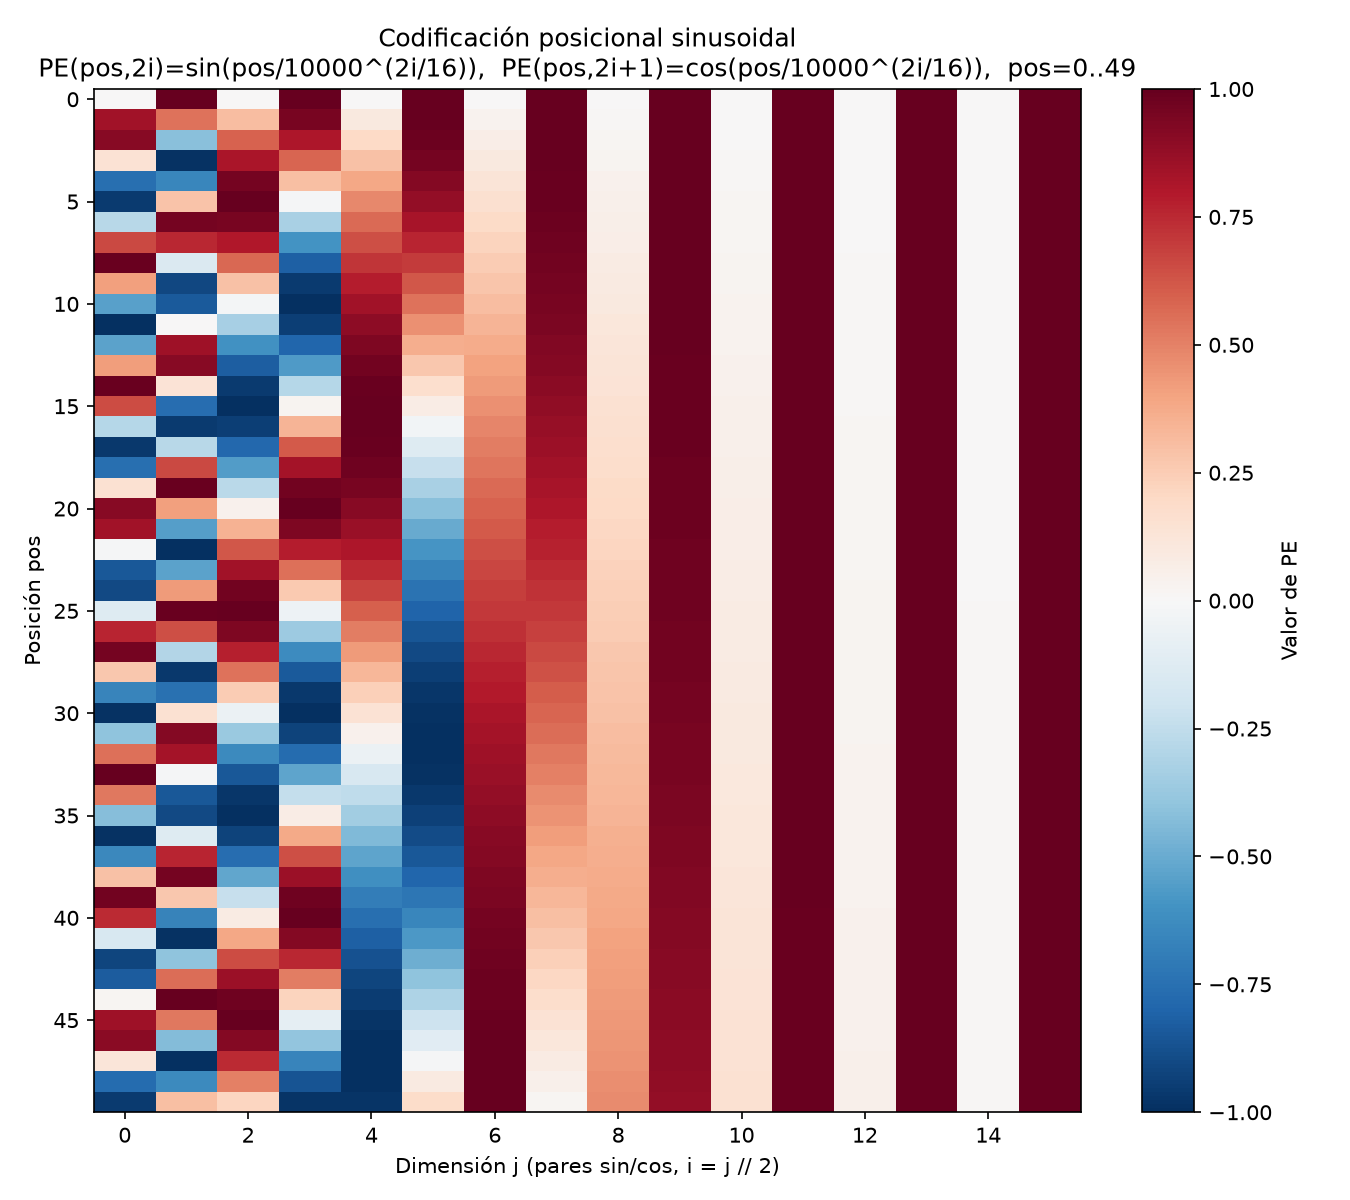

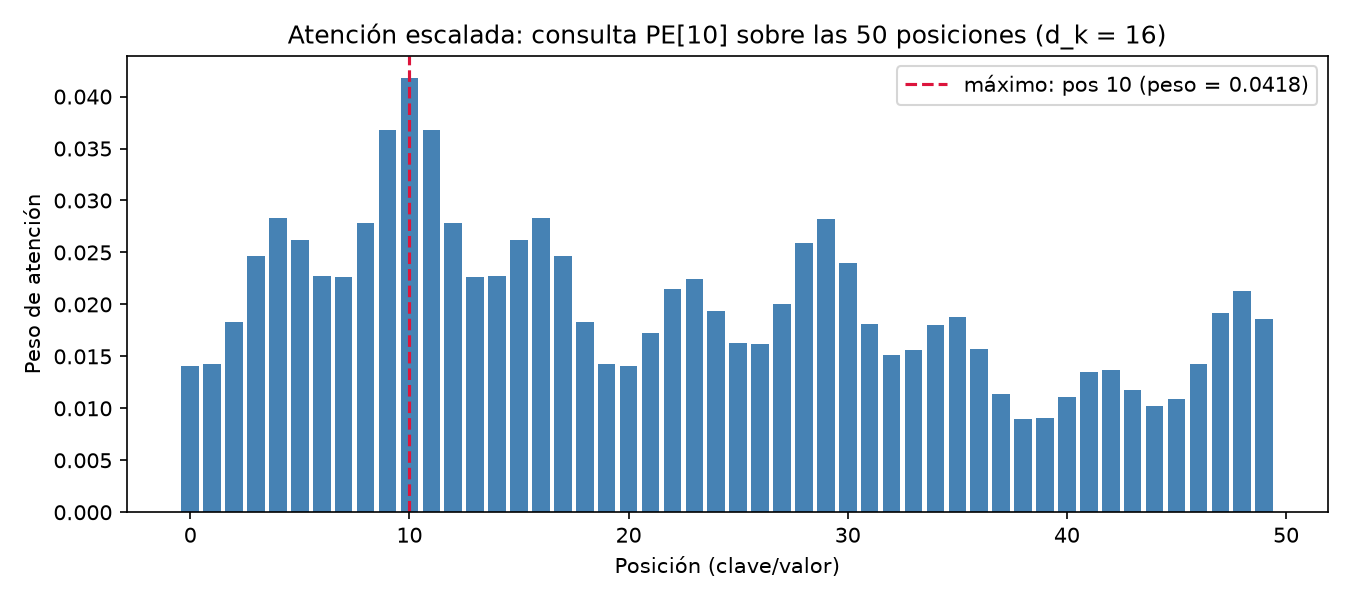

In [4]:
# Subtarea T3: código aprobado (se ejecuta en trabajo/T3/)
os.chdir(RAIZ / 'trabajo' / 'T3')

# -*- coding: utf-8 -*-
"""
SUBTAREA T3 — Parte 3 — Codificación posicional sinusoidal
- Calcula PE(pos,2i)=sin(pos/10000^(2i/d_model)) y PE(pos,2i+1)=cos(pos/10000^(2i/d_model))
  con d_model=16 para posiciones 0..49.
- Reporta PE[10,0], PE[10,1], PE[25,6].
- Dibuja la matriz PE (50x16) como mapa de calor (PNG).
- Reutiliza la función de atención de la Parte 1 (verificada contra entradas/T1.json):
  usa PE[10] como consulta y la matriz PE completa (50x16) como claves y valores,
  e identifica la posición con mayor peso y su valor.
"""

import json
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 0. Función de atención de la Parte 1 (softmax numéricamente estable)
#    d_k se infiere de la dimensión de los vectores consulta/clave.
# ----------------------------------------------------------------------
def softmax_estable(x, axis=-1):
    """Softmax numéricamente estable: resta el máximo de cada fila."""
    x_max = np.max(x, axis=axis, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=axis, keepdims=True)

def atencion_escalada(Q, K, V):
    """Attention(Q,K,V) = softmax(Q K^T / sqrt(d_k)) V  (misma función de la Parte 1)."""
    d_k = Q.shape[-1]
    scores = (Q @ K.T) / np.sqrt(d_k)
    pesos = softmax_estable(scores, axis=-1)
    salida = pesos @ V
    return scores, pesos, salida

# Verificación: la función debe reproducir los resultados de la Parte 1 (T1.json)
try:
    with open("entradas/T1.json", "r", encoding="utf-8") as f:
        t1 = json.load(f)
    Q1 = np.array(t1["Q_2x4"], dtype=float)
    K1 = np.array(t1["K_3x4"], dtype=float)
    V1 = np.array(t1["V_3x2"], dtype=float)
    _, pesos1, salida1 = atencion_escalada(Q1, K1, V1)
    ok_pesos = bool(np.allclose(pesos1, np.array(t1["pesos_atencion_2x3"], dtype=float)))
    ok_salida = bool(np.allclose(salida1, np.array(t1["salida_atencion_2x2"], dtype=float)))
    print(f"[Verificación Parte 1] pesos coinciden: {ok_pesos} | salida coincide: {ok_salida}")
except FileNotFoundError:
    print("[Aviso] entradas/T1.json no encontrado; se usa la función de atención tal cual.")

# ----------------------------------------------------------------------
# 1. Codificación posicional sinusoidal (d_model=16, posiciones 0..49)
# ----------------------------------------------------------------------
d_model = 16
n_pos = 50
posiciones = np.arange(n_pos)

PE = np.zeros((n_pos, d_model), dtype=float)
for pos in posiciones:
    for i in range(d_model // 2):
        angulo = pos / (10000.0 ** (2.0 * i / d_model))
        PE[pos, 2 * i] = np.sin(angulo)       # PE(pos, 2i)
        PE[pos, 2 * i + 1] = np.cos(angulo)   # PE(pos, 2i+1)

PE_10_0 = float(PE[10, 0])
PE_10_1 = float(PE[10, 1])
PE_25_6 = float(PE[25, 6])

# ----------------------------------------------------------------------
# 2. Atención: consulta = PE[10], claves y valores = PE completa (50x16)
#    Aquí d_k = 16 (dimensión de los vectores), sqrt(d_k) = 4.
# ----------------------------------------------------------------------
Q_pe = PE[10:11, :]   # (1, 16)
K_pe = PE             # (50, 16)
V_pe = PE             # (50, 16)

scores_pe, pesos_pe_mat, salida_pe = atencion_escalada(Q_pe, K_pe, V_pe)
pesos_pe = pesos_pe_mat.flatten()  # (50,)

posicion_mayor_peso = int(np.argmax(pesos_pe))
valor_mayor_peso = float(pesos_pe[posicion_mayor_peso])

# ----------------------------------------------------------------------
# 3. Guardar todas las cifras en resultados.json (precisión completa)
# ----------------------------------------------------------------------
resultados = {
    "d_model": int(d_model),
    "num_posiciones": int(n_pos),
    "PE_10_0": PE_10_0,
    "PE_10_1": PE_10_1,
    "PE_25_6": PE_25_6,
    "posicion_mayor_peso": posicion_mayor_peso,
    "valor_mayor_peso": valor_mayor_peso,
    "pesos_atencion_PE10_sobre_50_posiciones": [float(x) for x in pesos_pe],
    "salida_atencion_PE_16": [float(x) for x in salida_pe.flatten()],
    "PE_matriz_50x16": [[float(x) for x in fila] for fila in PE],
}
with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)

# ----------------------------------------------------------------------
# 4. Impresión de las cifras principales
# ----------------------------------------------------------------------
print("\n--- Parte 3: Codificación posicional sinusoidal (d_model=16, pos 0..49) ---")
print(f"PE[10, 0] = sin(10 / 10000^0)      = {PE_10_0!r}")
print(f"PE[10, 1] = cos(10 / 10000^0)      = {PE_10_1!r}")
print(f"PE[25, 6] = sin(25 / 10000^(6/16)) = {PE_25_6!r}")

print("\nAtención con PE[10] como consulta y PE (50x16) como claves/valores (d_k=16):")
top5 = np.argsort(pesos_pe)[::-1][:5]
for idx in top5:
    print(f"  posición {int(idx):2d} -> peso = {pesos_pe[idx]:.10f}")
print(f"\nPosición con mayor peso: {posicion_mayor_peso}")
print(f"Valor del mayor peso:    {valor_mayor_peso!r}")

# ----------------------------------------------------------------------
# 5. Figuras
# ----------------------------------------------------------------------
# Mapa de calor de la matriz PE (50 x 16)
plt.figure(figsize=(9, 8))
im = plt.imshow(PE, aspect="auto", cmap="RdBu_r", vmin=-1.0, vmax=1.0, origin="upper")
plt.colorbar(im, label="Valor de PE")
plt.xlabel("Dimensión j (pares sin/cos, i = j // 2)")
plt.ylabel("Posición pos")
plt.title("Codificación posicional sinusoidal\n"
          "PE(pos,2i)=sin(pos/10000^(2i/16)),  PE(pos,2i+1)=cos(pos/10000^(2i/16)),  pos=0..49")
plt.xticks(ticks=np.arange(0, d_model, 2))
plt.yticks(ticks=np.arange(0, n_pos, 5))
plt.tight_layout()
plt.savefig("mapa_calor_codificacion_posicional.png", dpi=150)
plt.close()

# (complemento) Pesos de atención de la consulta PE[10] sobre las 50 posiciones
plt.figure(figsize=(9, 4))
plt.bar(np.arange(n_pos), pesos_pe, color="steelblue")
plt.axvline(posicion_mayor_peso, color="crimson", linestyle="--",
            label=f"máximo: pos {posicion_mayor_peso} (peso = {valor_mayor_peso:.4f})")
plt.xlabel("Posición (clave/valor)")
plt.ylabel("Peso de atención")
plt.title("Atención escalada: consulta PE[10] sobre las 50 posiciones (d_k = 16)")
plt.legend()
plt.tight_layout()
plt.savefig("pesos_atencion_PE10.png", dpi=150)
plt.close()

print("\nFiguras guardadas: mapa_calor_codificacion_posicional.png, pesos_atencion_PE10.png")
print("Resultados guardados en resultados.json")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T3')

### Codificación sinusoidal (d_model = 16, posiciones 0–49)

$$PE(pos,2i)=\sin\!\left(pos/10000^{2i/d_{model}}\right),\qquad PE(pos,2i+1)=\cos\!\left(pos/10000^{2i/d_{model}}\right)$$

con $d_{model}=16$ y $pos=0,\dots,49$, lo que produce una matriz $PE\in\mathbb{R}^{50\times 16}$. Valores reportados:

| Entrada | Fórmula | Valor |
|---|---|---:|
| PE[10, 0] | $\sin(10/10000^{0})$ | -0.5440 |
| PE[10, 1] | $\cos(10/10000^{0})$ | -0.8391 |
| PE[25, 6] | $\sin(25/10000^{6/16})$ | 0.7108 |



El mapa de calor de PE muestra el patrón característico: las primeras dimensiones oscilan rápido (longitudes de onda cortas) y las últimas casi no varían a lo largo de las 50 posiciones (longitudes de onda largas), de modo que cada par de dimensiones codifica la posición a una escala distinta.

### Atención de PE[10] sobre las 50 posiciones

Se reutiliza la función de atención de la Parte 1 (el código verifica antes su consistencia con los resultados de la Parte 1), con PE[10] como única consulta y la matriz completa PE (50 × 16) como claves y valores ($d_k = 16$). Los mayores pesos son:

| Posición | Peso |
|---:|---:|
| **10** | **0.0418** |
| 9 | 0.0368 |
| 11 | 0.0368 |
| 4 | 0.0283 |
| 16 | 0.0283 |

**Respuesta: la posición que recibe el mayor peso es la 10, con un peso de 0.0418.** La distribución es simétrica alrededor de la consulta (9 y 11 empatan, igual que 4 y 16): el producto punto entre codificaciones sinusoidales depende del desplazamiento relativo $pos-10$, de modo que posiciones equidistantes reciben el mismo peso. Esta es la propiedad que permite al modelo atender en función de posiciones relativas.



## Parte 4 — Pregunta conceptual

**¿Qué problema resuelve la división por $\sqrt{d_k}$ y qué le pasaría al gradiente del softmax sin ella?**

**(1) Origen del problema: los puntajes crecen con $d_k$.** Como señala el paper (nota al pie 4), si las componentes de $q$ y $k$ son variables aleatorias independientes con media 0 y varianza 1, el producto punto $q\cdot k=\sum_{i=1}^{d_k}q_i k_i$ tiene media 0 y **varianza $d_k$**: su magnitud típica crece como $\sqrt{d_k}$. Dividir por $\sqrt{d_k}$ devuelve los puntajes a una escala comparable independientemente de la dimensión.

**(2) La evidencia de la Parte 2: softmax saturado sin escalar.** Sin escalar, con $d_k=64$ el peso máximo es 0.9511 y la entropía cae a 0.3537 bits, muy por debajo del máximo de 3.3219 bits para 10 claves: la distribución es casi un one-hot. Con $d_k=512$ ocurre lo mismo (peso máximo 0.7503, entropía 0.8114 bits). Con el escalado, las entropías suben a 2.9802 y 3.0363 bits y los pesos máximos bajan a 0.2480 y 0.1945: distribuciones suaves, repartidas entre varias claves. Con $d_k=4$ el efecto es leve (3.0792 → 3.2542 bits), coherente con que el problema aparece cuando $d_k$ es grande.

**(3) Sin escalado, el gradiente del softmax se anula.** El gradiente que llega a los puntajes a través del softmax es $\partial L/\partial z = p\odot\big(g-(p^{\top}g)\mathbf{1}\big)$, gobernado por el jacobiano $\mathrm{diag}(p)-pp^{\top}$. Cuando $p$ es casi one-hot ($p_{\max}\to 1$), los términos diagonales $p_i(1-p_i)\to 0$ y los cruzados $p_i p_j\to 0$: **el gradiente se desvanece para todos los puntajes**, sea cual sea el gradiente ascendente $g$. La atención queda "congelada" en un patrón casi determinista y el modelo no puede aprender a redistribuirla; además, ese gradiente mínimo es el que debe propagarse hacia $Q$ y $K$, frenando también el aprendizaje de las proyecciones. Es exactamente la región de "gradientes extremadamente pequeños" que describe el paper.

**(4) Qué resuelve la escala.** Al dividir por $\sqrt{d_k}$, los puntajes mantienen una varianza del orden de 1 y el softmax opera en su zona responsiva: las entropías medidas (2.9802–3.2542 bits) quedan cerca del máximo y los pesos no se saturan, de modo que el jacobiano conserva términos no despreciables y el gradiente fluye. Como el escalado preserva el orden de los puntajes, no cambia qué clave es más relevante; solo evita la sobreconfianza, dejando al modelo la posibilidad de ajustar la mezcla de valores.

**(5) Relación con el paper.** Vaswani et al. (2017) lo plantean en los mismos términos: *"We suspect that for large values of dk, the dot products grow large in magnitude, pushing the softmax function into regions where it has extremely small gradients. To counteract this effect, we scale the dot products by 1/√dk."* El experimento de la Parte 2 cuantifica esa sospecha. El régimen es directamente relevante para la arquitectura: el Transformer usa $h=8$ cabezas con $d_k=d_{model}/h=64$, precisamente el caso en el que aquí el colapso sin escalar es más severo (0.3537 bits). El paper prefiere el producto punto pese a esto porque es mucho más rápido y eficiente en espacio (se apoya en multiplicación de matrices altamente optimizada), y observa que para $d_k$ pequeño los mecanismos aditivo y de producto punto rinden de forma similar, lo cual es consistente con la diferencia leve de nuestra fila $d_k=4$.